# CondMidiPatchy — conditioned-MIDI measurewise dataset visualization

Visualizes the joint-sequence dataset packed by `tools/midi/buildCondMidiMeasurewise.py`:
each song is ONE sequence `[lilylet score patches] ++ [midi event patches]`, with a custom
windowed/block attention mask coupling midi measures to lilylet measures.

A short sample is used as the running example.

In [1]:
from pathlib import Path
import sys, os

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt

from starry.lilylet.data.patchifier import LilyletTokenizer
from starry.midi.tokenizer import MidiTokenizer
from starry.midi.data.condPatchy import CondMidiPatchy, _get_store, build_vis

DATASET_DIR = Path.home() / 'data' / 'lilylet' / 'midi-measurewise' / 'test20260629'
ROOT = str(DATASET_DIR / 'cond-midi.lmmw.pt')
print('repo:', REPO_ROOT)
print('root:', ROOT)

repo: /home/camus/work/deep-starry
root: /home/camus/data/lilylet/midi-measurewise/test20260629/cond-midi.lmmw.pt


## 1. Load the store and pick the shortest sample as the example

In [2]:
store = _get_store(ROOT)
idx = store.artifact
print('format     :', idx['format'])
print('tokenizers :', idx['tokenizers'])
print('items      :', len(store))

# shortest sample = clearest example
lengths = [(i, store.get(i)['patches'].shape[0]) for i in range(len(store))]
EX = min(lengths, key=lambda kv: kv[1])[0]
item = store.get(EX)
L = int(item['lyl_count'])
T = item['patches'].shape[0]
print(f'\nexample #{EX}: id={item["id"]}')
print(f'  T={T}  lyl_count L={L}  midi patches={T - L}')
print(f'  M_lyl={item["M_lyl"]}  M_midi={item["M_midi"]}')

format     : cond-midi-measurewise-patches-sharded
tokenizers : {'lyl': {'vocab_size': 256}, 'midi': {'vocab_size': 41}}
items      : 215

example #109: id=20250409_160536_Classical_Schubert, Franz_Art Song_postinst
  T=917  lyl_count L=129  midi patches=788
  M_lyl=17  M_midi=17


## 2. Sequence layout: modality + measure indices

`modality` 0=lilylet / 1=midi; `measures` = each patch's own measure; `src_measures` =
lilylet-aligned measure (midi i → source_measure). The `<eom>` patches terminate each midi measure.

eom patch positions (midi measure ends): [160, 210, 259, 308, 333, 373, 428, 483, 511, 560, 615, 697, 737, 783, 820, 898, 915] 
eom count: 17 == M_midi: 17


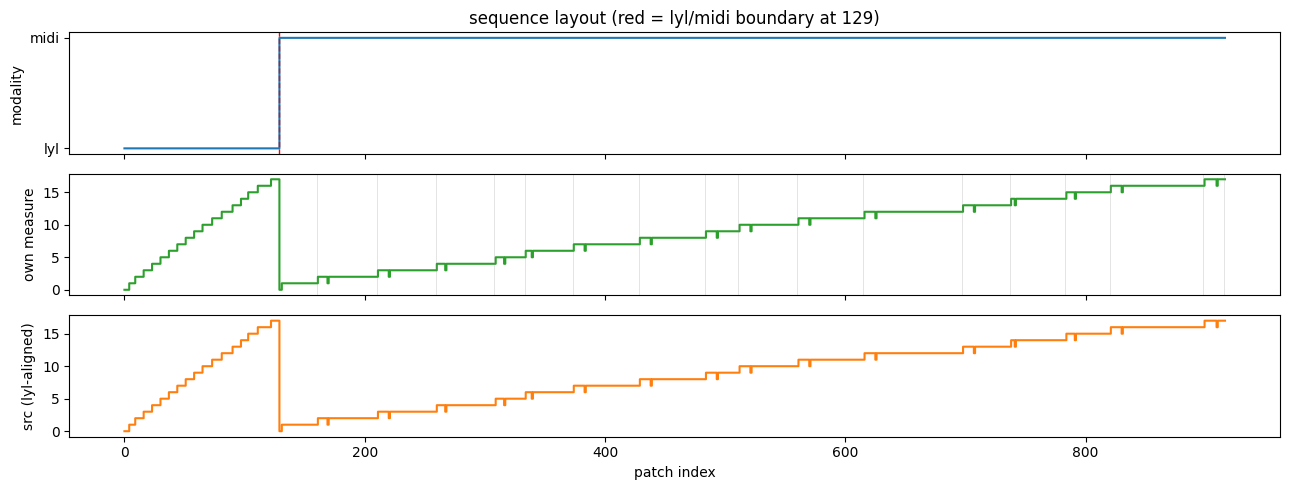

In [3]:
mt = MidiTokenizer()
mod = item['modality'].numpy()
own = item['measures'].numpy()
src = item['src_measures'].numpy()
patches = item['patches'].long()

eom_rows = ((patches[:, 0] == mt.eom_id) & (item['modality'] == 1)).nonzero().flatten().tolist()
print('eom patch positions (midi measure ends):', eom_rows[:20], '...' if len(eom_rows) > 20 else '')
print('eom count:', len(eom_rows), '== M_midi:', item['M_midi'])

fig, ax = plt.subplots(3, 1, figsize=(13, 5), sharex=True)
ax[0].plot(mod, drawstyle='steps-post'); ax[0].set_ylabel('modality'); ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(['lyl', 'midi'])
ax[0].axvline(L, color='r', ls='--', lw=1); ax[0].set_title(f'sequence layout (red = lyl/midi boundary at {L})')
ax[1].plot(own, drawstyle='steps-post', color='tab:green'); ax[1].set_ylabel('own measure')
ax[2].plot(src, drawstyle='steps-post', color='tab:orange'); ax[2].set_ylabel('src (lyl-aligned)')
for r in eom_rows:
    ax[1].axvline(r, color='gray', alpha=0.3, lw=0.5)
ax[2].set_xlabel('patch index')
plt.tight_layout(); plt.show()

## 3. Decode the patches back to text

lilylet patches → lilylet tokens; midi patches → MidiText event lines.

In [4]:
lt = LilyletTokenizer(str(REPO_ROOT / 'assets' / 'lilylet-tokenizer.json'))

def decode_lyl_patch(row):
    toks = [lt.text_by_id.get(int(t), '?') for t in row if int(t) not in (lt.pad_id, lt.bos_id, lt.eos_id)]
    return ''.join(toks)

print('=== lilylet segment (first 8 patches) ===')
for i in range(min(8, L)):
    print(f'  [{i:3d}] m{own[i]:>2}  {decode_lyl_patch(patches[i])!r}')

print('\n=== midi segment (first 12 patches) ===')
for i in range(L, min(L + 12, T)):
    line = mt.decode_event(patches[i].tolist())
    tag = '<eom>' if int(patches[i, 0]) == mt.eom_id else ''
    print(f'  [{i:4d}] m{own[i]:>2}  {tag:5} {line!r}')

=== lilylet segment (first 8 patches) ===
  [  0] m 0  ''
  [  1] m 0  '[staves "1 {2-3}"]\n'
  [  2] m 0  '[instrument-1 "Voice"]\n'
  [  3] m 0  '[instrument-2-3 "Piano"]\n'
  [  4] m 1  '[r:0/16]\\key bf \\major \\time'
  [  5] m 1  ' 3/4 \\clef "treble" \\tempo 4=92 '
  [  6] m 1  '^\\markup "Andante" f8 \\\\\\'
  [  7] m 1  '\n\\staff "1" \\clef "treble" r8 \\\\'

=== midi segment (first 12 patches) ===
  [ 129] m 0        'ticks_per_beat 1e0'
  [ 130] m 0        'format_type 1'
  [ 131] m 1        'key_signature 0 fe 0'
  [ 132] m 1        'set_tempo 0 9f38e'
  [ 133] m 1        'control_change 0 0 79 0'
  [ 134] m 1        'control_change 0 0 64 0'
  [ 135] m 1        'control_change 0 0 65 0'
  [ 136] m 1        'control_change 0 0 6 c'
  [ 137] m 1        'control_change 0 0 64 7f'
  [ 138] m 1        'control_change 0 0 65 7f'
  [ 139] m 1        'program_change 0 0 0'
  [ 140] m 1        'control_change 0 0 7 64'


## 4. The custom attention mask

Built by `build_vis`: lyl→lyl full causal, lyl→midi forbidden, midi→lyl cross block
(`j<=i<j+W_cross`, lyl header globally visible), midi→midi windowed-causal by measure
(`[m-W_midi+1, m]`). True = query (row) may attend key (col).

vis shape: (917, 917) | density: 0.169


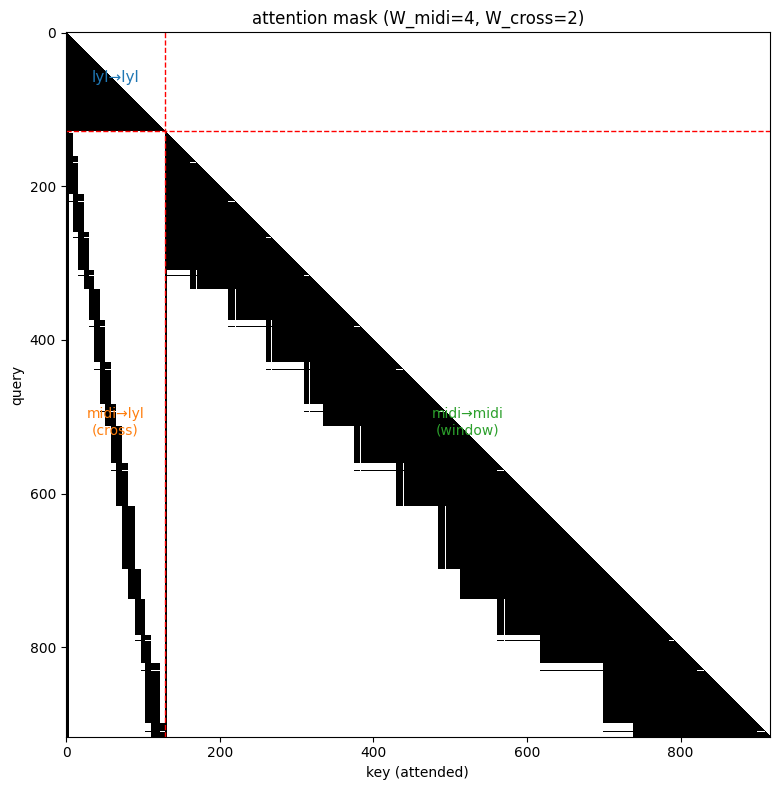

In [5]:
W_MIDI, W_CROSS = 4, 2
vis = build_vis(item['modality'].long(), item['measures'].long(), item['src_measures'].long(), W_MIDI, W_CROSS)
print('vis shape:', tuple(vis.shape), '| density: %.3f' % vis.float().mean().item())

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(vis.numpy(), cmap='Greys', interpolation='nearest', aspect='equal')
ax.axvline(L - 0.5, color='r', ls='--', lw=1); ax.axhline(L - 0.5, color='r', ls='--', lw=1)
ax.set_xlabel('key (attended)'); ax.set_ylabel('query'); ax.set_title(f'attention mask (W_midi={W_MIDI}, W_cross={W_CROSS})')
ax.text(L * 0.5, L * 0.5, 'lyl\u2192lyl', color='tab:blue', ha='center', fontsize=11)
ax.text(L * 0.5, L + (T - L) * 0.5, 'midi\u2192lyl\n(cross)', color='tab:orange', ha='center', fontsize=10)
ax.text(L + (T - L) * 0.5, L + (T - L) * 0.5, 'midi\u2192midi\n(window)', color='tab:green', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

## 5. Mask sanity checks

Confirm the four block rules and that no real query row is empty (SDPA safety).

In [6]:
v = vis
checks = {
    'no future leak (upper triangle empty)': not v.triu(1).any().item(),
    'lyl→lyl is full lower-triangular':   bool((v[:L, :L] == torch.tril(torch.ones(L, L, dtype=torch.bool))).all()),
    'lyl→midi all forbidden':             not v[:L, L:].any().item(),
    'every query row non-empty':             bool((v.sum(1) >= 1).all()),
}
for k, ok in checks.items():
    print(('  OK  ' if ok else ' FAIL ') + k)
assert all(checks.values())

# midi->midi window width per query, EXCLUDING the always-visible measure-0 header
midi_q = np.arange(L, T)
own_t = item['measures'].long()
spans = []
for q in midi_q:
    ks = v[q, L:].nonzero().flatten()
    ms = own_t[L + ks]
    ms = ms[ms > 0]                      # drop the midi header (measure 0, globally visible)
    if len(ms):
        spans.append(int(ms.max() - ms.min()) + 1)
print('\nmidi→midi attended measure-span (excl. header): max=%d (<= W_midi=%d)' % (max(spans), W_MIDI))
assert max(spans) <= W_MIDI

  OK  no future leak (upper triangle empty)
  OK  lyl→lyl is full lower-triangular
  OK  lyl→midi all forbidden
  OK  every query row non-empty

midi→midi attended measure-span (excl. header): max=4 (<= W_midi=4)


## 6. Cross-coupling zoom: which lilylet measures does each midi measure see?

For each midi measure i, the visible lilylet measures should be `{0 (header)} ∪ [i-W_cross+1 .. i]`.

In [7]:
# one representative midi patch per midi measure (its eom row), show visible lyl measures
rows = []
for r in eom_rows:
    i = int(own[r])
    vis_lyl_measures = sorted(set(int(own[k]) for k in v[r, :L].nonzero().flatten().tolist()))
    rows.append((i, vis_lyl_measures))
for i, vm in rows[:12]:
    print(f'  midi measure {i:>2} (eom) sees lyl measures: {vm}')

  midi measure  1 (eom) sees lyl measures: [0, 1]
  midi measure  2 (eom) sees lyl measures: [0, 1, 2]
  midi measure  3 (eom) sees lyl measures: [0, 2, 3]
  midi measure  4 (eom) sees lyl measures: [0, 3, 4]
  midi measure  5 (eom) sees lyl measures: [0, 4, 5]
  midi measure  6 (eom) sees lyl measures: [0, 5, 6]
  midi measure  7 (eom) sees lyl measures: [0, 6, 7]
  midi measure  8 (eom) sees lyl measures: [0, 7, 8]
  midi measure  9 (eom) sees lyl measures: [0, 8, 9]
  midi measure 10 (eom) sees lyl measures: [0, 9, 10]
  midi measure 11 (eom) sees lyl measures: [0, 10, 11]
  midi measure 12 (eom) sees lyl measures: [0, 11, 12]


## 7. Through the feeder: a collated batch

Confirm `collateBatch` produces the 4D bool mask, supervision targets on midi only, and
padding handled (use two samples of different length).

In [8]:
ds = CondMidiPatchy(ROOT, '0..19/20', device='cpu', shuffle=False, w_midi=W_MIDI, w_cross=W_CROSS)
order = sorted(range(len(store)), key=lambda i: store.get(i)['patches'].shape[0])
batch = ds.collateBatch([ds._item(order[0]), ds._item(order[3])])
for k, val in batch.items():
    print(f'  {k:16} {tuple(val.shape)} {val.dtype}')

tgt = batch['input_targets']; modb = batch['modality']
print('\ntargets only on midi segment:', bool(((tgt == 1) & (modb == 0)).sum() == 0))
print('target count per sample      :', tgt.sum(1).tolist())
print('attn_mask is 4D bool         :', batch['attn_mask'].dim() == 4 and batch['attn_mask'].dtype == torch.bool)

  input_patches    (2, 1824, 16) torch.int64
  input_masks      (2, 1824) torch.int64
  input_targets    (2, 1824) torch.int64
  input_positions  (2, 1824) torch.int64
  attn_mask        (2, 1, 1824, 1824) torch.bool
  modality         (2, 1824) torch.int64
  lyl_counts       (2,) torch.int64

targets only on midi segment: True
target count per sample      : [787, 1579]
attn_mask is 4D bool         : True
